In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

engine = create_engine("sqlite:///../data/db/bluestock_mf.db")

nav = pd.read_sql("SELECT * FROM fact_nav", engine)
fund_master = pd.read_sql("SELECT * FROM dim_fund", engine)
transactions = pd.read_sql("SELECT * FROM fact_transactions", engine)
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

nav["nav_date"] = pd.to_datetime(nav["nav_date"])
nav = nav.sort_values(["amfi_code", "nav_date"])
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])

print("NAV rows:", len(nav))
print("Transaction rows:", len(transactions))

NAV rows: 46000
Transaction rows: 32778


In [3]:
var_cvar_results = []
for code in nav["amfi_code"].unique():
    returns = nav[nav["amfi_code"] == code]["daily_return"].dropna()
    if len(returns) < 30:
        continue
    var_95 = np.percentile(returns, 5)
    cvar_95 = returns[returns <= var_95].mean()
    var_cvar_results.append({"amfi_code": code, "VaR_95": var_95, "CVaR_95": cvar_95})

var_cvar_df = pd.DataFrame(var_cvar_results)
var_cvar_df = var_cvar_df.merge(fund_master[["amfi_code", "scheme_name"]], on="amfi_code")
var_cvar_df = var_cvar_df.sort_values("VaR_95")
var_cvar_df.to_csv("../data/processed/var_cvar_report.csv", index=False)
var_cvar_df.head(10)

,amfi_code,VaR_95,CVaR_95,scheme_name
22,119599,-0.026859,-0.032384,SBI Small Cap Fund - Direct Plan - Growth
17,119095,-0.026188,-0.031667,Axis Small Cap Fund - Regular - Growth
4,101207,-0.026021,-0.032459,ABSL Small Cap Fund - Regular - Growth
11,118634,-0.025438,-0.032304,Nippon India Small Cap Fund - Regular - Growth
21,119598,-0.024507,-0.030595,SBI Small Cap Fund - Regular Plan - Growth
39,149324,-0.023483,-0.031036,DSP Small Cap Fund - Regular - Growth
7,102886,-0.019220,-0.023251,UTI Mid Cap Fund - Regular - Growth
2,100033,-0.019034,-0.023456,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
25,120505,-0.018892,-0.024342,ICICI Pru Midcap Fund - Regular - Growth
16,119094,-0.018480,-0.024260,Axis Midcap Fund - Regular - Growth


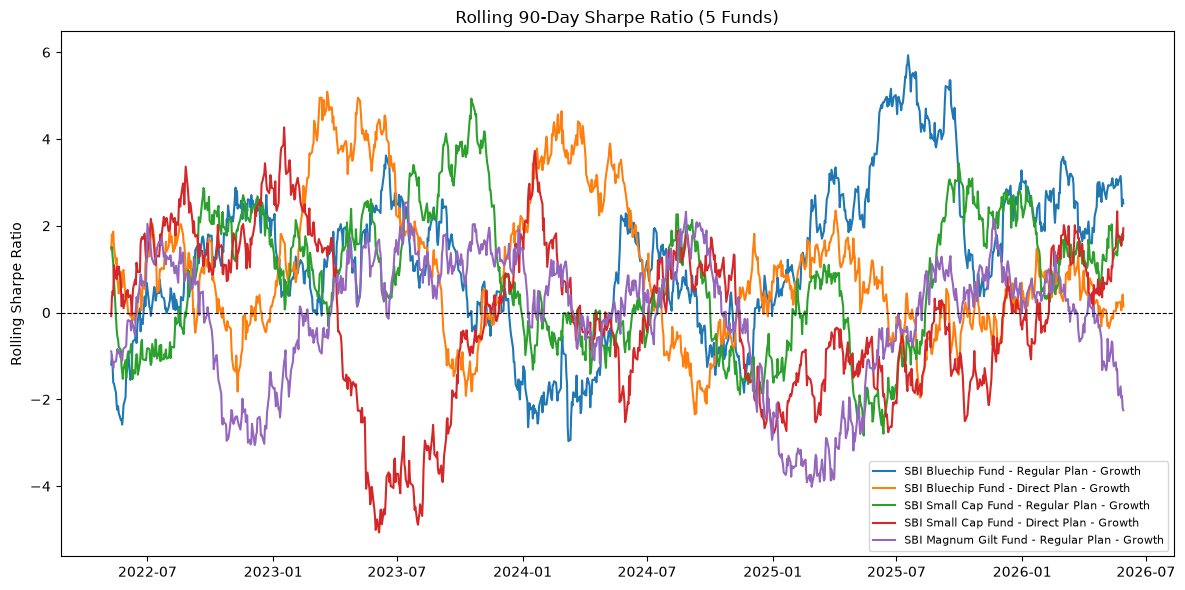

In [4]:
Rf = 0.065
top5_codes = fund_master["amfi_code"].head(5).tolist()

fig, ax = plt.subplots(figsize=(12, 6))
for code in top5_codes:
    fund_data = nav[nav["amfi_code"] == code].sort_values("nav_date").copy()
    rolling_mean = fund_data["daily_return"].rolling(90).mean()
    rolling_std = fund_data["daily_return"].rolling(90).std()
    fund_data["rolling_sharpe"] = ((rolling_mean * 252) - Rf) / (rolling_std * np.sqrt(252))
    scheme_name = fund_master[fund_master["amfi_code"] == code]["scheme_name"].values[0]
    ax.plot(fund_data["nav_date"], fund_data["rolling_sharpe"], label=scheme_name)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Rolling 90-Day Sharpe Ratio (5 Funds)")
ax.set_ylabel("Rolling Sharpe Ratio")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("../reports/charts/11_rolling_sharpe.png", dpi=200)
plt.show()

In [5]:
first_tx = transactions.groupby("investor_id")["transaction_date"].min().reset_index()
first_tx["cohort_year"] = first_tx["transaction_date"].dt.year
transactions_with_cohort = transactions.merge(first_tx[["investor_id", "cohort_year"]], on="investor_id")

sip_tx = transactions_with_cohort[transactions_with_cohort["transaction_type"] == "Sip"]

cohort_summary = sip_tx.groupby("cohort_year").agg(
    avg_sip_amount=("amount_inr", "mean"),
    total_invested=("amount_inr", "sum"),
    num_investors=("investor_id", "nunique")
).reset_index()

# Top fund preference per cohort
top_fund_per_cohort = (
    sip_tx.groupby(["cohort_year", "amfi_code"])["amount_inr"].sum()
    .reset_index()
    .sort_values(["cohort_year", "amount_inr"], ascending=[True, False])
    .groupby("cohort_year").first()
    .reset_index()[["cohort_year", "amfi_code"]]
    .rename(columns={"amfi_code": "top_fund_code"})
)

cohort_summary = cohort_summary.merge(top_fund_per_cohort, on="cohort_year")
cohort_summary.to_csv("../data/processed/cohort_analysis.csv", index=False)
cohort_summary

,cohort_year,avg_sip_amount,total_invested,num_investors,top_fund_code
0,2024,10996.885825,214978121,4624,125498
1,2025,13505.209581,2255370,138,119599


In [6]:
sip_only = transactions[transactions["transaction_type"] == "Sip"].sort_values(["investor_id", "transaction_date"])
sip_counts = sip_only.groupby("investor_id").size()
eligible_investors = sip_counts[sip_counts >= 6].index

continuity_results = []
for inv_id in eligible_investors:
    dates = sip_only[sip_only["investor_id"] == inv_id]["transaction_date"].sort_values()
    gaps = dates.diff().dt.days.dropna()
    avg_gap = gaps.mean()
    continuity_results.append({
        "investor_id": inv_id,
        "avg_gap_days": avg_gap,
        "at_risk": avg_gap > 35
    })

continuity_df = pd.DataFrame(continuity_results)
continuity_df.to_csv("../data/processed/sip_continuity.csv", index=False)

print("Total eligible investors (6+ SIPs):", len(continuity_df))
print("At-risk investors (avg gap > 35 days):", continuity_df["at_risk"].sum())
print("At-risk %:", round(continuity_df["at_risk"].mean() * 100, 1))
continuity_df.head(10)

Total eligible investors (6+ SIPs): 1362
At-risk investors (avg gap > 35 days): 1332
At-risk %: 97.8


,investor_id,avg_gap_days,at_risk
0,INV000004,85.400000,True
1,INV000008,70.400000,True
2,INV000010,64.800000,True
3,INV000011,40.166667,True
4,INV000012,57.000000,True
5,INV000013,55.333333,True
6,INV000014,75.333333,True
7,INV000023,58.571429,True
8,INV000028,93.600000,True
9,INV000029,60.666667,True


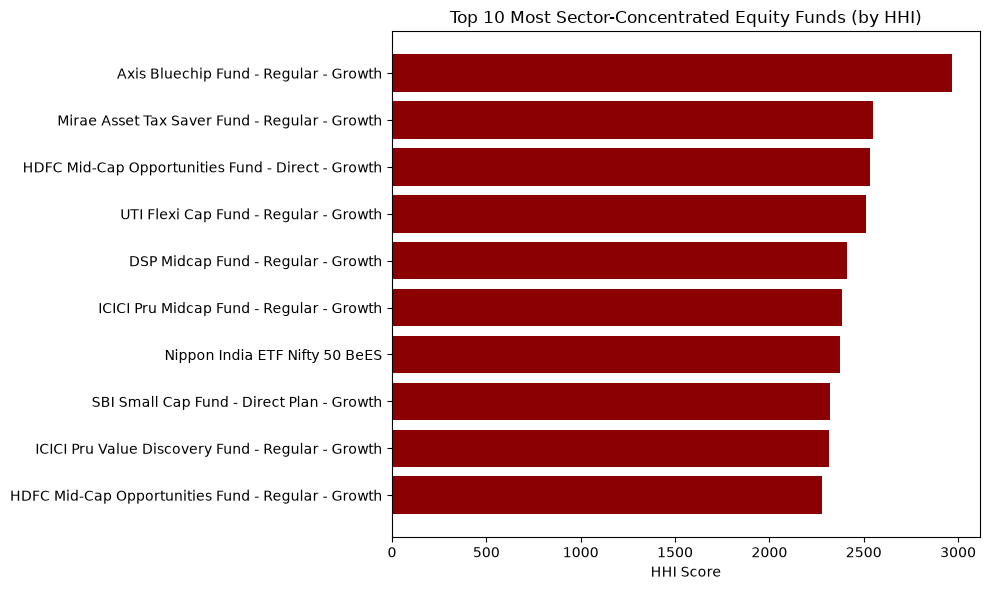

In [ ]:
hhi_results = []

for code in holdings["amfi_code"].unique():

    fund_holdings = holdings[holdings["amfi_code"] == code]

    sector_weights = fund_holdings.groupby("sector")["weight_pct"].sum()

    hhi = ((sector_weights / 100) ** 2).sum() * 10000

    hhi_results.append({
        "amfi_code": code,
        "HHI": hhi
    })


# Create HHI DataFrame
hhi_df = pd.DataFrame(hhi_results)


# Convert amfi_code to the same data type
hhi_df["amfi_code"] = hhi_df["amfi_code"].astype(str).str.strip()
fund_master["amfi_code"] = fund_master["amfi_code"].astype(str).str.strip()


# Merge
hhi_df = hhi_df.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)


# Sort
hhi_df = hhi_df.sort_values("HHI", ascending=False)


# Save CSV
hhi_df.to_csv(
    "../data/processed/sector_hhi.csv",
    index=False
)


# Plot
fig, ax = plt.subplots(figsize=(10, 6))

top10 = hhi_df.head(10).sort_values("HHI")

ax.barh(
    top10["scheme_name"],
    top10["HHI"],
    color="darkred"
)

ax.set_title("Top 10 Most Sector-Concentrated Equity Funds (by HHI)")
ax.set_xlabel("HHI Score")

plt.tight_layout()

plt.savefig(
    "../reports/charts/12_sector_hhi.png",
    dpi=200
)

plt.show()

## Advanced Analytics — Key Insights

1. **Highest tail-risk funds are concentrated in Small Cap and Mid Cap categories** — SBI Small Cap Fund (Direct), Axis Small Cap Fund, and ABSL Small Cap Fund show the worst VaR (95%) around -2.6% to -2.7% daily, with CVaR near -3.2%, confirming small/mid-cap schemes carry the highest downside tail risk in this dataset.

2. **All 5 tracked funds show highly volatile rolling Sharpe ratios that repeatedly cross below zero** — SBI Magnum Gilt Fund dipped as low as -3.5 in mid-2022, and SBI Small Cap (Direct) dropped to nearly -5 in mid-2023, before recovering into strongly positive territory (4-6) by 2025-2026. This swinging pattern shows risk-adjusted performance is highly regime-dependent, not stable over time.

3. **The 2024 cohort invested far more in both scale and volume** — 4,624 investors starting in 2024 invested a combined ₹21.5 crore (avg ₹10,997/SIP), compared to just 138 investors in the 2025 cohort investing ₹22.6 lakh total (avg ₹13,505/SIP). 2024 was the dominant onboarding year by investor count and total capital.

4. **SIP continuity is a major concern — 97.8% of long-term SIP investors are "at-risk."** Of 1,362 investors with 6+ SIP transactions, 1,332 show an average gap exceeding 35 days between payments, suggesting most investors are not maintaining a consistent monthly SIP cadence despite being classified as long-term.

5. **Axis Bluechip Fund is the most sector-concentrated equity fund (HHI ≈ 2,950)**, followed by Mirae Asset Tax Saver and HDFC Mid-Cap Opportunities (Direct), both near HHI 2,550. Higher HHI means these portfolios lean heavily into fewer sectors, reducing diversification and raising sector-specific risk — worth flagging for risk-conscious investors comparing "same category" funds.